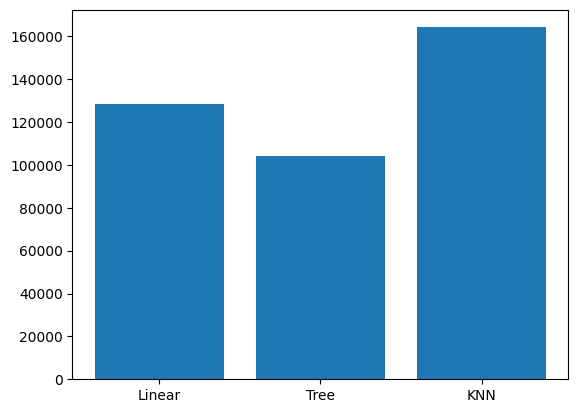

In [1]:

DATA_PATH = "/kaggle/input/datasets/alyelbadry/house-pricing-dataset/house_prices.csv"
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

df = pd.read_csv(DATA_PATH).dropna()
X = pd.get_dummies(df.drop("price", axis=1))
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

models = {"Linear": LinearRegression(),"Tree": DecisionTreeRegressor(),"KNN": KNeighborsRegressor()}
results = []

for n,m in models.items():
    m.fit(X_train,y_train)
    p = m.predict(X_test)
    results.append([n, mean_absolute_error(y_test,p), np.sqrt(mean_squared_error(y_test,p)), r2_score(y_test,p)])

table = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"])
table.to_csv("RQ1_table.csv", index=False)

x = np.arange(len(table))
plt.figure()
plt.bar(x, table["MAE"])
plt.xticks(x, table["Model"])
plt.savefig("RQ1_figure.pdf")
plt.show()
